
# Task 5: Poisson Solver in 2D

Implement a Python function to solve the **Poisson problem** on a square domain with homogeneous Dirichlet boundary conditions, using the **5-point finite difference Laplacian**:

$$
\nabla^2 u = -2 \sin(x) \sin(y),
\qquad (x, y) \in [0, 2\pi] \times [0, 2\pi],
$$

with
$$
u(x,0) = 0, \quad u(x, 2\pi) = 0, \quad u(0,y) = 0, \quad u(2\pi,y) = 0.
$$

### (a) Implement the solver


In [1]:
import numpy as np
from scipy import sparse # Use sparse matrix for A to be able to use greater values of m


def poisson(m):
    """
    Solve the 2D Poisson equation:
        ∇²u = -2 sin(x) sin(y),   (x,y) ∈ [0,2π] × [0,2π],
        u = 0 on the boundary.

    Parameters
    ----------
    m : int
        Number of interior grid points in each direction.

    Returns
    -------
    X, Y : 1D ndarrays
        Meshgrid of all grid points including boundaries.
    U : 2D ndarray
        Numerical solution at all grid points.
    """
    # Step 1: Discretize domain [0, 2π] × [0, 2π]
    
    # In this case X and Y are the same, but not in general
    X = np.linspace(start=0, stop=2*np.pi, num=m+2) # In total m+2 points
    Y = np.linspace(start=0, stop=2*np.pi, num=m+2) # In total m+2 points
    
    h = X[1]-X[0] # distance between 2 consecutive points (in this case same for X and Y)
    
    # Step 2: Build sparse matrix A for the 5-point Laplacian
    
    A = np.zeros((m**2,m**2)) # first index is value of k where the eqn is centered, second index are the elements


    for j in range(m): # 0,...,m-1: is in our notation 1,...,m
        for i in range(m): # 0,...,m-1: is in our notation 1,...,m
            
            # index of u in the vector of length m**2 (BCs = 0)
            k = m*j + i # k(i,j)
            
            # Set entries of A:
            
            # (i,j)
            A[k,k] = - 4
            
            # (i-1, j) if not in boundary
            if i>0:  # k(i-1, j) = m*j +i-1 = k(i,j) -1
                A[k, k-1] = 1
                
                
            # (i+1, j) if not in boundary
            if i<m-1: # k(i+1, j) = m*j +i+1 = k(i,j) +1
                A[k, k+1] = 1
        
            # (i, j-1) if not in boundary
            if j>0: # k(i, j-1) = m*(j-1) +i = k(i,j) -m
                A[k, k-m] = 1
                
            # (i, j+1) if not in boundary
            if j<m-1: # k(i, j+1) = m*(j+1) +i = k(i,j) +m
                A[k, k+m] = 1
                
    # Now divide A by h**2
    A/= h**2

    # Finally we use sparse to use an sparse array instead of a matrix
    A = sparse.csr_matrix(A)
    
    
    # Step 3: Assemble RHS vector with f(x,y) = -2 sin(x) sin(y)
    f_function = lambda x,y: -2*np.sin(x)*np.sin(y) # NOTE: HORRIBLE PRACTICE
    
    rhs = np.zeros(m**2)
    
    for j in range(m):
        y = Y[j+1] # Y includes boundary points at 0 and m+1, so we take values at 1,...,m 
        for i in range(m):
            
            x = X[i+1] # X includes boundary points at 0 and m+1, so we take values at 1,...,m 
            
            k = m*j+i
                        
            rhs[k] = f_function(x, y)
    
    # Step 4: Solve linear system AU = F
    # spsolve optimized to solve sparse matrices
    U_vector = sparse.linalg.spsolve(A, rhs) # Vector of length m**2 (the index is k = m*j+i)
    
    # Step 5: Reconstruct solution including boundary values

    U = np.zeros((m+2, m+2)) # uij for i,j=0,..., m+1
    
    
    # Change lengths to range(m+2) if necessary to include BCs using
    # if j == 0 ... if j==m+1 ...  out of inner loop with continue
    # and so with i as well
    for j in range(m):
        for i in range(m):
            
            k = m*j + i
            
            U[i+1, j+1] =  U_vector[k] # U at i, j = 0 or m+1 is 0 bc of BCs, so we only change values for i,j= 1,...,m.
            
    
    return X, Y, U


### (b) Verify numerical convergence

1. Compute the solution for increasing values of `m` (e.g. `m = 8, 16, 32, 64`).
2. Compare with the exact solution

   $$
   u(x, y) = \sin(x)\sin(y),
   $$

   and compute the error in $\ell^2$ and $\ell^\infty$ norms.
3. Plot the errors vs. $h$ (grid spacing) in a log-log plot, and verify that the scheme is **second-order accurate**.

---

I am going to use an $l^2$ norm normalized. The motivation is the following one:

Consider the error in $L^2$. Then, the norm of the error is

$$\left \lVert e\right \rVert_{L^2}^2 = \int_{a}^b \int_{c}^d u(x, y) - \tilde{u}(x,y) dy dx$$

with $\tilde{u}$ being the approximation. Then, this equality can be approximated by

$$\left \lVert e\right \rVert_{L^2}^2 \approx \sum_i \sum_j (u_{ij} - \tilde{u}_{ij}) h_y h_x = h_y h_x \left \lVert e\right \rVert_{l^2}^2$$

which is the norm in $l^2$ normalized.

In [2]:
def dist_l2(u_approx, u_exact, h_x, h_y):
    """Returns the normalized l2 norm of the error. 
    
        The real l2 norm would be
            np.sqrt(np.sum((u_approx-u_exact)**2))
        
        The normalized one is
            np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))
            
        with h_x, h_y the size step in x and y coordinates respectively.

    Args:
        u_approx (1D ndarray): Approximation of u
        u_exact (1D ndarray): Exact value of u
        h_x (float): step size in x
        h_y (float): step size in y

    Returns:
        1D ndarray: L2 Error
    """
    return np.sqrt(h_x * h_y * np.sum((u_approx-u_exact)**2))

def dist_linf(u_approx, u_exact):
    return np.max(np.abs(u_approx - u_exact))

def apply_exact(X, Y, u):
    """Apply u to the grid

    Args:
        X, Y : 1D ndarrays
                Meshgrid of all grid points including boundaries.
        u (function): function to evaluate
        
    Returns
        U: 2D ndarrays
                Evaluation of U in the grid
    """
    
    # We may have different lengths
    n = len(X)
    m = len(Y)
    
    U = np.zeros((n, m))
    
    for i in range(n):
        x = X[i]
        for j in range(m):
            y = Y[j]
            U[i,j] = u(x, y)
            
    return U

We calculate and plot the errors now.

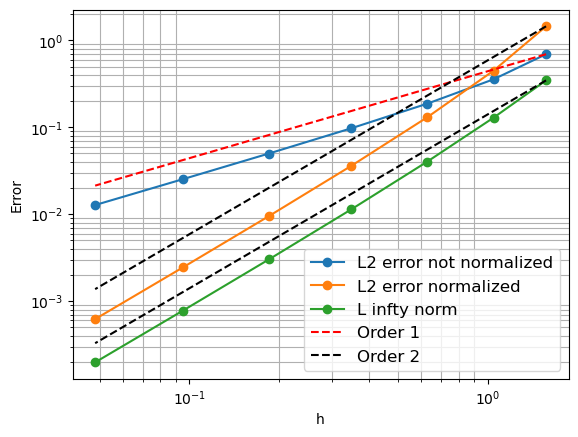

In [3]:

import matplotlib.pyplot as plt
# Only show numbers with 4 decimal points in print
np.set_printoptions(
    formatter={'float_kind': lambda x: f"{x:.4f}"}
)


m_list = [2**k for k in range(1,8)]

h_list = np.array([2*np.pi / (m+2) for m in m_list]) # m inner points, so m+2 in total i. e. 2*pi = (m+2)*h

u = lambda x, y: np.sin(x)*np.sin(y)

error_l2 = []
error_l2_normalized = []
error_linf = []
for m in m_list:
    X, Y, U = poisson(m)
    
    U_exact = apply_exact(X, Y, u)
    
    error_l2.append(dist_l2(U, U_exact, h_x= 1, h_y = 1)) # l2 error without the normalization
    error_l2_normalized.append(dist_l2(U, U_exact, h_x= X[1]-X[0], h_y = Y[1]-Y[0]))
    error_linf.append(dist_linf(U, U_exact))

# Errors
plt.loglog(h_list, error_l2, "o-", label = "L2 error not normalized")
plt.loglog(h_list, error_l2_normalized, "o-", label = "L2 error normalized")
plt.loglog(h_list, error_linf, "o-", label = "L infty norm")

# Lines of convergence rates
plt.loglog(h_list, (error_l2[0]/h_list[0]**1)*h_list**1, "r--", label = "Order 1")
plt.loglog(h_list, (error_l2_normalized[0]/h_list[0]**2)*h_list**2, "k--", label = "Order 2")
plt.loglog(h_list, (error_linf[0]/h_list[0]**2)*h_list**2, "k--")

plt.legend(fontsize=12, loc="best")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="minor")

plt.show()

We see how the errors are of order 2 except the one which is not normalized. Therefore, our method is of second order.